Saving customer_support_tickets.csv to customer_support_tickets.csv


[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


📋 Available Columns:
 ['Ticket ID', 'Customer Name', 'Customer Email', 'Customer Age', 'Customer Gender', 'Product Purchased', 'Date of Purchase', 'Ticket Type', 'Ticket Subject', 'Ticket Description', 'Ticket Status', 'Resolution', 'Ticket Priority', 'Ticket Channel', 'First Response Time', 'Time to Resolution', 'Customer Satisfaction Rating']


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129534 (\N{RECEIPT}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


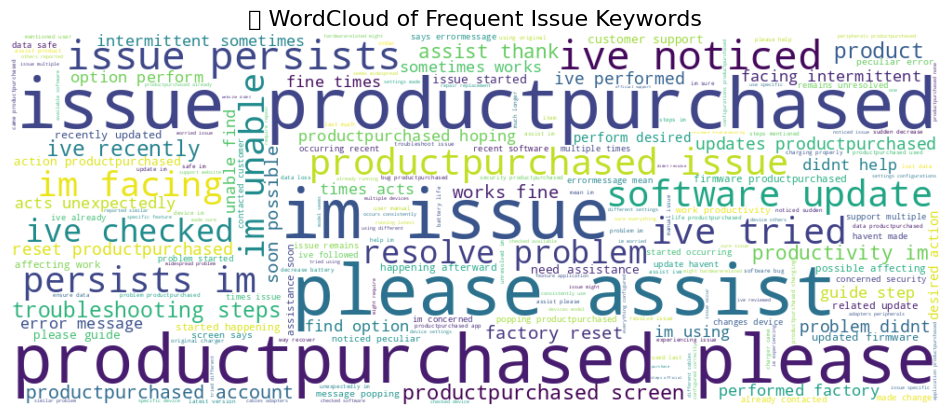

<ipython-input-17-7aaa48be7f64>:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, y='Ticket Type', order=df['Ticket Type'].value_counts().head(10).index, palette='viridis')
<ipython-input-17-7aaa48be7f64>:54: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128204 (\N{PUSHPIN}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


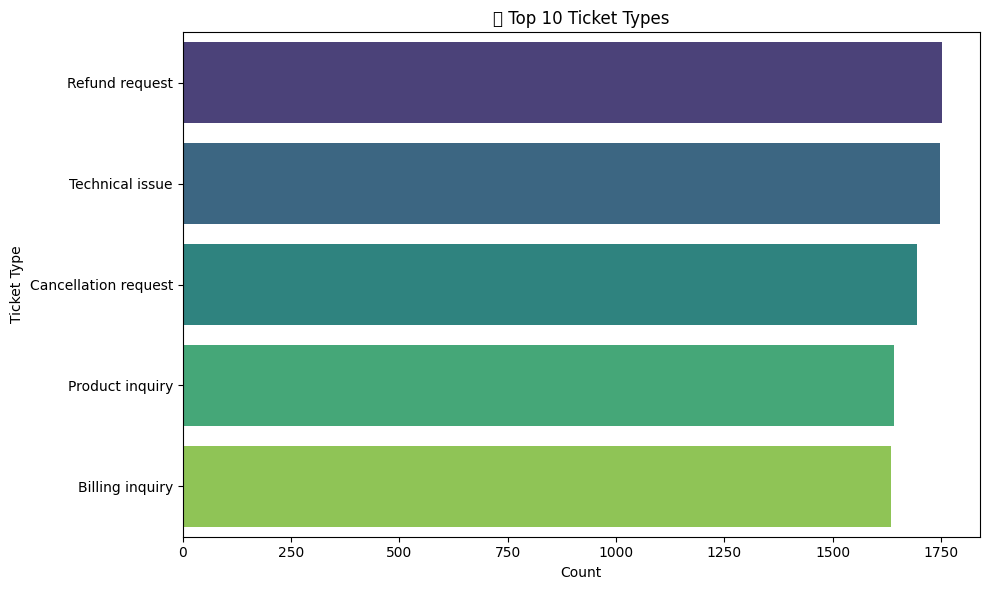

<ipython-input-17-7aaa48be7f64>:62: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 129000 (\N{LARGE YELLOW SQUARE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


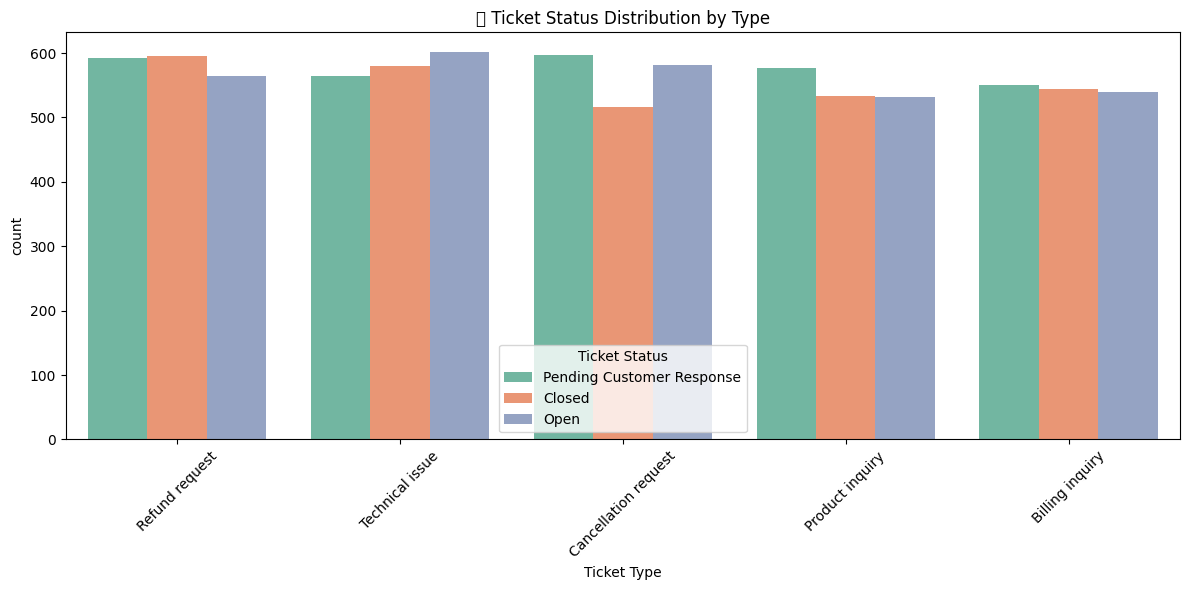

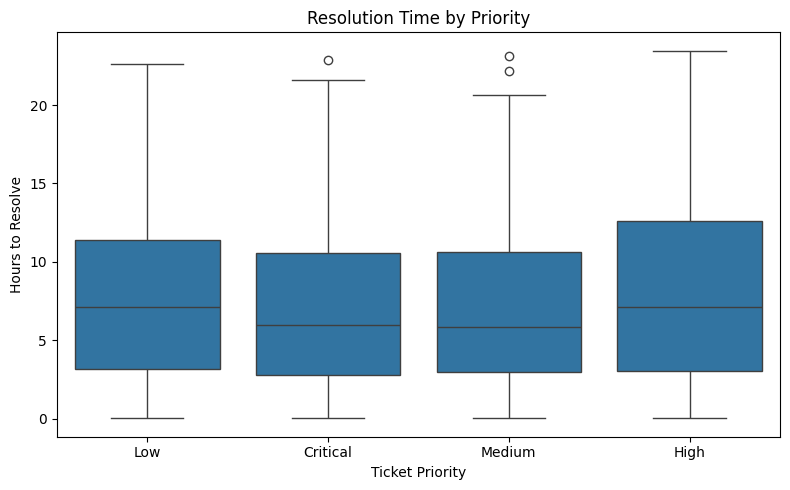

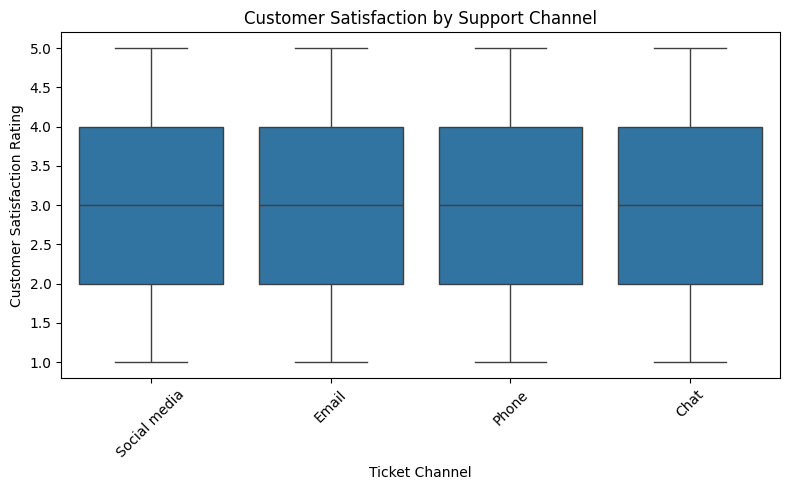

In [17]:
# STEP 1: Upload the CSV
from google.colab import files
uploaded = files.upload()

# STEP 2: Install & import necessary libraries
!pip install -q wordcloud
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from wordcloud import WordCloud
import nltk
import string
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# STEP 3: Download NLTK data
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('punkt_tab')

# STEP 4: Load the data
file_name = next(iter(uploaded))
df = pd.read_csv(file_name)
print("📋 Available Columns:\n", df.columns.tolist())

# STEP 5: Clean the Ticket Description column (No TextBlob)
stop_words = set(stopwords.words("english"))

def clean_text(text):
    if pd.isnull(text):
        return ""
    text = text.lower()
    text = ''.join([c for c in text if c not in string.punctuation])
    tokens = word_tokenize(text)
    tokens = [word for word in tokens if word not in stop_words]
    return " ".join(tokens)

df["Cleaned_Text"] = df["Ticket Description"].apply(clean_text)

# STEP 6: 🧾 WordCloud of Frequent Issue Keywords
wordcloud = WordCloud(width=1000, height=400, background_color='white').generate(" ".join(df["Cleaned_Text"]))
plt.figure(figsize=(12,6))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title("🧾 WordCloud of Frequent Issue Keywords", fontsize=16)
plt.show()

# STEP 7: 📌 Top 10 Ticket Types
plt.figure(figsize=(10,6))
sns.countplot(data=df, y='Ticket Type', order=df['Ticket Type'].value_counts().head(10).index, palette='viridis')
plt.title("📌 Top 10 Ticket Types")
plt.xlabel("Count")
plt.ylabel("Ticket Type")
plt.tight_layout()
plt.show()

# STEP 8: 🟨 Ticket Status Distribution by Type
plt.figure(figsize=(12,6))
sns.countplot(data=df, x="Ticket Type", hue="Ticket Status", order=df['Ticket Type'].value_counts().head(10).index, palette='Set2')
plt.title("🟨 Ticket Status Distribution by Type")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# 9. Resolution Time Analysis
df['Time to Resolution'] = pd.to_datetime(df['Time to Resolution'], errors='coerce')
df['First Response Time'] = pd.to_datetime(df['First Response Time'], errors='coerce')
df['Resolution Hours'] = (df['Time to Resolution'] - df['First Response Time']).dt.total_seconds() / 3600
df['Resolution Hours'] = df['Resolution Hours'].fillna(0)


plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Resolution Hours'] > 0], x='Ticket Priority', y='Resolution Hours')
plt.title("Resolution Time by Priority")
plt.ylabel("Hours to Resolve")
plt.tight_layout()
plt.show()

# 10. Satisfaction Rating by Channel
plt.figure(figsize=(8, 5))
sns.boxplot(data=df[df['Customer Satisfaction Rating'] > 0], x='Ticket Channel', y='Customer Satisfaction Rating')
plt.title("Customer Satisfaction by Support Channel")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()